In [9]:
!pip install deepchem
!pip install rdkit

In [1]:
# Импорт необходимых библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem, RDLogger
from rdkit.Chem import Draw, Descriptors
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import random
import re
from collections import Counter
import warnings
import torch.nn.functional as F
import time

# Игнорирование предупреждений RDKit
RDLogger.DisableLog('rdApp.*')
warnings.filterwarnings('ignore')

# Установка случайных семян для воспроизводимости
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Проверка доступности GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используется устройство: {device}")

Используется устройство: cpu


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("basu369victor/zinc250k")

print("Path to dataset files:", path)


Path to dataset files: C:\Users\ro517\.cache\kagglehub\datasets\basu369victor\zinc250k\versions\1


In [3]:
# Загрузка данных ZINC15 (подвыборка 10,000 молекул)
# В реальном сценарии данные можно скачать с http://zinc.docking.org/
# Для демонстрации создадим искусственный датасет или загрузим из файла
import os

file_path = os.path.join(path, '250k_rndm_zinc_drugs_clean_3.csv')
data = pd.read_csv(file_path)
data = data.drop('logP', axis=1).drop('qed', axis=1).drop('SAS', axis=1)
print("Данные успешно загружены из файла zinc15_subsample.csv")

# Отображение первых 5 строк
print("\nПервые 5 SMILES-строк:")
print(data.head())

Данные успешно загружены из файла zinc15_subsample.csv

Первые 5 SMILES-строк:
                                              smiles
0          CC(C)(C)c1ccc2occ(CC(=O)Nc3ccccc3F)c2c1\n
1     C[C@@H]1CC(Nc2cncc(-c3nncn3C)c2)C[C@@H](C)C1\n
2  N#Cc1ccc(-c2ccc(O[C@@H](C(=O)N3CCCC3)c3ccccc3)...
3  CCOC(=O)[C@@H]1CCCN(C(=O)c2nc(-c3ccc(C)cc3)n3c...
4  N#CC1=C(SCC(=O)Nc2cccc(Cl)c2)N=C([O-])[C@H](C#...


In [4]:
# Предобработка SMILES
def canonicalize_smiles(smiles):
    """Преобразование SMILES в канонический вид с помощью RDKit"""
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is not None:
            return Chem.MolToSmiles(mol, canonical=True)
    except:
        pass
    return None

# Применение канонизации
print("\nКанонизация SMILES...")
data['canonical_smiles'] = data['smiles'].apply(canonicalize_smiles)

# Удаление некорректных SMILES
initial_count = len(data)
data = data.dropna(subset=['canonical_smiles'])
print(f"Удалено {initial_count - len(data)} некорректных SMILES")

# Фильтрация по длине (оставляем от 10 до 80 символов)
data = data[data['canonical_smiles'].apply(lambda x: 10 <= len(x) <= 80)]
print(f"После фильтрации по длине осталось {len(data)} молекул")

# Создание словаря символов
all_chars = set()
for sm in data['canonical_smiles']:
    all_chars.update(sm)
all_chars = sorted(list(all_chars))

# Добавление специальных токенов
PAD_TOKEN = '<PAD>'
START_TOKEN = '<START>'
END_TOKEN = '<END>'
all_chars = [PAD_TOKEN, START_TOKEN, END_TOKEN] + all_chars




Канонизация SMILES...
Удалено 0 некорректных SMILES
После фильтрации по длине осталось 249079 молекул


In [5]:
# Создание mapping для символов
char_to_idx = {char: idx for idx, char in enumerate(all_chars)}
idx_to_char = {idx: char for char, idx in char_to_idx.items()}
vocab_size = len(all_chars)
print(f"\nРазмер словаря: {vocab_size} символов")
print("Примеры символов:", all_chars)


Размер словаря: 36 символов
Примеры символов: ['<PAD>', '<START>', '<END>', '#', '(', ')', '+', '-', '/', '1', '2', '3', '4', '5', '6', '7', '=', '@', 'B', 'C', 'F', 'H', 'I', 'N', 'O', 'P', 'S', '[', '\\', ']', 'c', 'l', 'n', 'o', 'r', 's']


In [49]:
# Преобразование SMILES в последовательности индексов
def smiles_to_sequence(smiles, max_len=80):
    """Преобразование SMILES в последовательность индексов с padding"""
    seq = [char_to_idx[START_TOKEN]]
    for char in smiles:
        if char in char_to_idx:
            seq.append(char_to_idx[char])
    seq.append(char_to_idx[END_TOKEN])

    # Padding до максимальной длины
    if len(seq) < max_len:
        seq += [char_to_idx[PAD_TOKEN]] * (max_len - len(seq))
    elif len(seq) > max_len:
        seq = seq[:max_len-1] + [char_to_idx[END_TOKEN]]

    return seq

# Установка максимальной длины последовательности
max_len = 80
sequences = [smiles_to_sequence(sm, max_len) for sm in data['canonical_smiles']]

# Разделение данных на обучение и валидацию
train_seq, val_seq = train_test_split(sequences[:10000], test_size=0.1, random_state=42)

# Преобразование в тензоры PyTorch
train_tensor = torch.tensor(train_seq, dtype=torch.long)
val_tensor = torch.tensor(val_seq, dtype=torch.long)

# Создание DataLoader
batch_size = 64
train_dataset = TensorDataset(train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

print(f"\nРазмер обучающей выборки: {len(train_dataset)} молекул")
print(f"Размер последовательности: {max_len}")
print("Пример последовательности:", train_seq[0])


Размер обучающей выборки: 9000 молекул
Размер последовательности: 80
Пример последовательности: [1, 19, 19, 19, 24, 30, 9, 30, 30, 30, 4, 23, 19, 4, 16, 24, 5, 19, 23, 19, 4, 16, 24, 5, 30, 10, 30, 30, 33, 30, 10, 5, 30, 30, 9, 19, 31, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [50]:
def generate_smiles(generator, num_samples=100, max_len=max_len, temperature=1.0):
    generator.eval()
    z = torch.randn(num_samples, generator.latent_dim, device=next(generator.parameters()).device)
    with torch.no_grad():
        logits = generator(z)  # (B, L, V)
        if temperature != 1.0:
            logits = logits / temperature
        probs = torch.softmax(logits, dim=-1)
        # Сэмплирование вместо argmax (улучшает разнообразие)
        indices = torch.multinomial(probs.view(-1, probs.size(-1)), 1).view(probs.shape[:-1])
        # ИЛИ жадно: indices = probs.argmax(dim=-1)

    smiles_list = []
    for seq in indices.cpu().numpy():
        sm = []
        for idx in seq:
            if idx == char_to_idx[END_TOKEN]:
                break
            if idx not in [char_to_idx[PAD_TOKEN], char_to_idx[START_TOKEN]]:
                sm.append(idx_to_char[idx])
        smiles_list.append(''.join(sm))
    return smiles_list

# Функция для оценки метрик
def evaluate_metrics(generated_smiles, train_smiles):
    """Оценка метрик Validity, Uniqueness, Novelty"""
    if not generated_smiles:  # Защита от пустого списка
        return 0.0, 0.0, 0.0, []
    
    # Validity: процент химически корректных молекул
    valid_smiles = []
    for sm in generated_smiles:
        if sm.strip():  # Проверяем, что строка не пустая
            mol = Chem.MolFromSmiles(sm)
            if mol is not None:
                valid_smiles.append(Chem.MolToSmiles(mol, canonical=True))
    
    if not generated_smiles:
        return 0.0, 0.0, 0.0, []
    
    validity = len(valid_smiles) / len(generated_smiles) * 100
    
    # Uniqueness: процент уникальных молекул среди валидных
    if valid_smiles:
        unique_smiles = list(set(valid_smiles))
        uniqueness = len(unique_smiles) / len(valid_smiles) * 100
    else:
        uniqueness = 0
        unique_smiles = []
    
    # Novelty: процент молекул, отсутствующих в обучающей выборке
    if unique_smiles:
        train_set = set(train_smiles)
        novel_smiles = [sm for sm in unique_smiles if sm not in train_set]
        novelty = len(novel_smiles) / len(unique_smiles) * 100 if unique_smiles else 0
    else:
        novelty = 0
    
    return validity, uniqueness, novelty, valid_smiles


In [51]:
from torch.nn.utils import spectral_norm
# Архитектура WGAN-GP
class Generator(nn.Module):
    def __init__(self, latent_dim, hidden_dim, vocab_size, max_len, embed_dim=64):
        super().__init__()
        self.latent_dim = latent_dim
        self.hidden_dim = hidden_dim
        self.vocab_size = vocab_size
        self.max_len = max_len
        
        # Увеличиваем размеры и добавляем регуляризацию
        self.fc1 = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim * 4),
            nn.BatchNorm1d(hidden_dim * 4),
            nn.ReLU(),
            nn.Dropout(0.3)
        )
        
        self.fc2 = nn.Sequential(
            nn.Linear(hidden_dim * 4, max_len * hidden_dim),
            nn.BatchNorm1d(max_len * hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3)
        )
        
        # LSTM с dropout
        self.lstm = nn.LSTM(
            hidden_dim, hidden_dim,
            num_layers=2,
            batch_first=True,
            dropout=0.3,
            bidirectional=True  # Добавляем bidirectional
        )
        
        # Выходной слой
        self.fc_out = nn.Linear(hidden_dim * 2, vocab_size)  # *2 из-за bidirectional
        
    def forward(self, z):
        batch_size = z.size(0)
        x = self.fc1(z)
        x = self.fc2(x)
        x = x.view(batch_size, self.max_len, self.hidden_dim)
        x, _ = self.lstm(x)
        x = self.fc_out(x)
        return x
        
class Critic(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=256):
        super().__init__()
        self.embedding = spectral_norm(nn.Linear(vocab_size, embed_dim))
        
        # Добавляем BatchNorm
        self.bn1 = nn.BatchNorm1d(embed_dim)
        
        self.conv1 = nn.Sequential(
            nn.Conv1d(embed_dim, hidden_dim, kernel_size=5, padding=2),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3)
        )
        
        self.conv2 = nn.Sequential(
            nn.Conv1d(hidden_dim, hidden_dim, kernel_size=5, padding=2),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3)
        )
        
        # Используем оба типа pooling
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.max_pool = nn.AdaptiveMaxPool1d(1)
        
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, 1)
        )
        
    def forward(self, x):
        embedded = self.embedding(x)
        embedded = embedded.permute(0, 2, 1)
        embedded = self.bn1(embedded)
        
        x = self.conv1(embedded)
        x = self.conv2(x)
        
        # Конкатенируем avg и max pooling
        avg_pooled = self.avg_pool(x).squeeze(-1)
        max_pooled = self.max_pool(x).squeeze(-1)
        x = torch.cat([avg_pooled, max_pooled], dim=1)
        
        x = self.fc(x)
        return x
        
# Инициализация весов
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Linear') != -1:
        nn.init.xavier_normal_(m.weight, gain=0.02)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)
    elif classname.find('Conv') != -1:
        nn.init.xavier_normal_(m.weight, gain=0.02)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight, 1.0, 0.02)
        nn.init.constant_(m.bias, 0)

# Функция для вычисления градиентного штрафа
def compute_gradient_penalty(real_samples, fake_samples):
    """Вычисление градиентного штрафа с исправлениями"""
    batch_size = real_samples.size(0)
    
    # Случайная интерполяция между реальными и сгенерированными данными
    alpha = torch.rand(batch_size, 1, 1, device=device)
    alpha = alpha.expand_as(real_samples)
    interpolates = alpha * real_samples + (1 - alpha) * fake_samples
    interpolates = interpolates.requires_grad_(True)
    
    # Предсказание критика для интерполированных данных
    d_interpolates = critic(interpolates)
    
    # Вычисление градиентов
    fake = torch.ones(batch_size, 1, device=device, requires_grad=False)
    gradients = torch.autograd.grad(
        outputs=d_interpolates,
        inputs=interpolates,
        grad_outputs=fake,
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]
    
    # Норма градиентов и штраф
    gradients = gradients.view(batch_size, -1)
    gradient_norm = gradients.norm(2, dim=1)
    gradient_penalty = ((gradient_norm - 1) ** 2).mean()
    
    return gradient_penalty

In [52]:
# Создаем обратный словарь для преобразования индексов в символы
idx2char = {i: c for c, i in char_to_idx.items()}

def generate_molecules(generator, num_molecules=1000, latent_dim=100, 
                      temperature=0.8, device='cpu'):
    generator.eval()
    generated_smiles = []
    
    with torch.no_grad():
        for i in range(0, num_molecules, batch_size):
            current_batch = min(batch_size, num_molecules - i)
            z = torch.randn(current_batch, latent_dim).to(device)
            
            fake_logits = generator(z)
            fake_probs = F.softmax(fake_logits / temperature, dim=2)
            
            # Сэмплирование для разнообразия
            fake_indices = torch.multinomial(
                fake_probs.view(-1, vocab_size), 1
            ).view(current_batch, -1)
            
            for j in range(current_batch):
                indices = fake_indices[j].cpu().numpy()
                chars = []
                for idx in indices:
                    if idx == char_to_idx[END_TOKEN]:
                        break
                    if idx not in [char_to_idx[PAD_TOKEN], char_to_idx[START_TOKEN]]:
                        chars.append(idx_to_char[idx])
                
                if chars:
                    smiles = ''.join(chars)
                    # Проверка валидности
                    mol = Chem.MolFromSmiles(smiles)
                    if mol is not None:
                        generated_smiles.append(Chem.MolToSmiles(mol, canonical=True))
    
    generator.train()
    return generated_smiles

In [55]:
# Гиперпараметры обучения
lr = 0.00004
lrc = 0.00002
beta1 = 0.5
beta2 = 0.999
lambda_gp = 100
n_critic = 2  # Количество шагов критика на 1 шаг генератора
temperature = 0.8
clip_value = 0.5

# Инициализация моделей
latent_dim = 100
hidden_dim = 128
embed_dim = 32

generator = Generator(latent_dim, hidden_dim, vocab_size, max_len, embed_dim).to(device)
critic = Critic(vocab_size, embed_dim, hidden_dim).to(device)

generator.apply(weights_init)
critic.apply(weights_init)


# Оптимизаторы
optimizer_G = optim.Adam(generator.parameters(), lr=lr, betas=(beta1, beta2), weight_decay=1e-5)
optimizer_C = optim.Adam(critic.parameters(), lr=lrc, betas=(beta1, beta2))

ce_loss_fn = nn.CrossEntropyLoss(ignore_index=char_to_idx[PAD_TOKEN])

# Обучение WGAN-GP
num_epochs = 50
log_interval = 5  # ИЗМЕНЕНО: Чаще проверяем прогресс
fixed_z = torch.randn(16, latent_dim).to(device)

# Хранение истории
g_losses = []
c_losses = []
wasserstein_dists = []
best_validity = 0
best_generator = None
patience = 5  # Для ранней остановки
patience_counter = 0

print("\nНачало обучения WGAN-GP с исправлениями...")
print(f"Learning rates: G={lr}, C={lrc}")
print(f"Lambda GP: {lambda_gp}")
print(f"Gradient clip: {clip_value}")
start_time = time.time()

for epoch in range(num_epochs):
    epoch_c_loss = 0
    epoch_g_loss = 0
    epoch_wasserstein = 0
    batches = 0
    
    # ИЗМЕНЕНО: Добавляем режим MLE для первых 10 эпох вместо 20
    use_mle = epoch < 10
    mle_weight = max(0.1 * (10 - epoch) / 10, 0)  # Постепенно уменьшаем вес MLE
    
    for i, (real_seq,) in enumerate(tqdm(train_loader, desc=f"Эпоха {epoch+1}/{num_epochs}")):
        real_seq = real_seq.to(device)
        batch_size = real_seq.size(0)
        
        # ---------------------
        # Обучение критика (ИСПРАВЛЕНО)
        # ---------------------
        optimizer_C.zero_grad()
        
        real_onehot = F.one_hot(real_seq, num_classes=vocab_size).float()
        
        # Генерируем фейковые данные
        z = torch.randn(batch_size, latent_dim, device=device)
        fake_logits = generator(z)
        
        # Gumbel-Softmax с температурой (для обучения критика используем мягкие вероятности)
        fake_probs = F.gumbel_softmax(fake_logits, tau=temperature, hard=False, dim=-1)
        fake_probs_detached = fake_probs.detach()
        
        # Предсказания критика
        real_pred = critic(real_onehot)
        fake_pred = critic(fake_probs_detached)
        
        # Вычисляем расстояние Вассерштейна
        wasserstein_distance = -torch.mean(real_pred) + torch.mean(fake_pred)
        
        # Градиентный штраф (ИСПРАВЛЕНО: используем детаченные данные для интерполяции)
        gradient_penalty = compute_gradient_penalty(
            real_onehot.detach(), 
            fake_probs_detached
        )
        
        # Потери критика
        c_loss = wasserstein_distance + lambda_gp * gradient_penalty
        
        c_loss.backward()
        
        # ИЗМЕНЕНО: Более строгий gradient clipping для критика
        torch.nn.utils.clip_grad_norm_(critic.parameters(), max_norm=clip_value)
        
        optimizer_C.step()
        
        # ---------------------
        # Обучение генератора (ИСПРАВЛЕНО)
        # ---------------------
        if i % n_critic == 0:
            optimizer_G.zero_grad()
            
            z = torch.randn(batch_size, latent_dim, device=device)
            fake_logits = generator(z)
            
            # Для обучения генератора используем hard Gumbel-Softmax
            fake_probs_hard = F.gumbel_softmax(fake_logits, tau=temperature, hard=True, dim=-1)
            
            # Straight-through trick
            fake_indices = torch.argmax(fake_probs_hard.detach(), dim=-1)
            fake_onehot_hard = F.one_hot(fake_indices, num_classes=vocab_size).float()
            fake_probs_st = fake_probs_hard + (fake_onehot_hard - fake_probs_hard).detach()
            
            # Предсказание критика
            fake_pred = critic(fake_probs_st)
            
            # Потеря WGAN
            g_loss_wgan = -torch.mean(fake_pred)
            
            # Добавляем MLE потерю только в начале обучения
            if use_mle:
                input_seq = real_seq[:, :-1]
                target_seq = real_seq[:, 1:]
                logits_for_mle = fake_logits[:, :-1].reshape(-1, vocab_size)
                targets_flat = target_seq.reshape(-1)
                g_loss_mle = ce_loss_fn(logits_for_mle, targets_flat)
                g_loss = g_loss_wgan + mle_weight * g_loss_mle
            else:
                g_loss = g_loss_wgan
            
            g_loss.backward()
            
            # Gradient clipping для генератора
            torch.nn.utils.clip_grad_norm_(generator.parameters(), max_norm=clip_value)
            
            optimizer_G.step()
            
            epoch_g_loss += g_loss.item()
            batches += 1
        
        epoch_c_loss += c_loss.item()
        epoch_wasserstein += wasserstein_distance.item()
    
    # Средние потери за эпоху
    avg_c_loss = epoch_c_loss / len(train_loader)
    avg_g_loss = epoch_g_loss / max(batches, 1)
    avg_wasserstein = epoch_wasserstein / len(train_loader)
    
    c_losses.append(avg_c_loss)
    g_losses.append(avg_g_loss)
    wasserstein_dists.append(avg_wasserstein)
    
    # ==================== КОНТРОЛЬ СТАБИЛЬНОСТИ ====================
    # РАННЯЯ ОСТАНОВКА ПРИ ВЗРЫВЕ ГРАДИЕНТОВ
    if abs(avg_wasserstein) > 30:
        print(f"\n⚠ ВНИМАНИЕ: Взрыв градиентов на эпохе {epoch+1}")
        print(f"   Wasserstein = {avg_wasserstein:.4f} (слишком большой)")
        print(f"   Уменьшаем learning rates...")
        
        # Автоматическая корректировка learning rates
        for param_group in optimizer_G.param_groups:
            param_group['lr'] *= 0.5
        for param_group in optimizer_C.param_groups:
            param_group['lr'] *= 0.5
        
        patience_counter += 1
        if patience_counter >= 3:
            print(f"⚠ Ранняя остановка: множественные взрывы градиентов")
            break
    
    # СБРОС СЧЕТЧИКА, если обучение стабильно
    if abs(avg_wasserstein) < 10:
        patience_counter = max(0, patience_counter - 1)
    
    # Генерация и оценка
    if (epoch + 1) % log_interval == 0:
        generated_smiles = generate_molecules(
            generator, 
            num_molecules=1000,
            temperature=0.8,
            device=device
        )
        
        validity, uniqueness, novelty, valid_smiles = evaluate_metrics(
            generated_smiles, 
            data['canonical_smiles'].tolist()
        )
        
        print(f"\n[Эпоха {epoch+1}/{num_epochs}]")
        print(f"  Loss D: {avg_c_loss:.4f} | G: {avg_g_loss:.4f}")
        print(f"  Wasserstein: {avg_wasserstein:.4f} (цель: |W| < 10)")
        print(f"  Validity: {validity:.2f}% | Uniqueness: {uniqueness:.2f}%")
        
        # Отображение текущих learning rates
        current_lr_g = optimizer_G.param_groups[0]['lr']
        current_lr_c = optimizer_C.param_groups[0]['lr']
        print(f"  LR: G={current_lr_g:.6f}, C={current_lr_c:.6f}")
        
        if len(valid_smiles) > 0:
            print(f"  Примеры: {valid_smiles[:3]}")
        
        # Сохранение лучшей модели
        if validity > best_validity:
            best_validity = validity
            best_generator = generator.state_dict()
            patience_counter = 0  # Сбрасываем счетчик терпения
            
            torch.save({
                'epoch': epoch,
                'generator_state': best_generator,
                'critic_state': critic.state_dict(),
                'optimizer_G_state': optimizer_G.state_dict(),
                'optimizer_C_state': optimizer_C.state_dict(),
                'validity': validity,
                'losses': {
                    'g_losses': g_losses,
                    'c_losses': c_losses,
                    'wasserstein': wasserstein_dists
                },
                'hyperparams': {
                    'lr': lr,
                    'lrc': lrc,
                    'lambda_gp': lambda_gp,
                    'clip_value': clip_value
                }
            }, 'best_wgan_gp_model_stable.pth')
            
            print(f"  ✓ Новая лучшая модель! Validity: {validity:.2f}%")
        
        # Ранняя остановка при коллапсе (плохая валидность)
        if validity < 2 and epoch > 15:
            print(f" Ранняя остановка: коллапс генератора")
            break

# Общее время обучения
total_time = time.time() - start_time
print(f"\nОбучение завершено за {total_time/60:.2f} минут")

# Загрузка лучшей модели
if best_generator is not None:
    generator.load_state_dict(best_generator)
    print(f"Загружена лучшая модель с Validity = {best_validity:.2f}%")
    
    # Финальная оценка
    generated_smiles = generate_molecules(
        generator, 
        num_molecules=5000,
        temperature=0.8,
        device=device
    )
    
    validity, uniqueness, novelty, _ = evaluate_metrics(
        generated_smiles, 
        data['canonical_smiles'].tolist()
    )
    
    print(f"\nФинальные метрики лучшей модели:")
    print(f"  Validity: {validity:.2f}%")
    print(f"  Uniqueness: {uniqueness:.2f}%")
    print(f"  Novelty: {novelty:.2f}%")


Начало обучения WGAN-GP с исправлениями...
Learning rates: G=4e-05, C=2e-05
Lambda GP: 100
Gradient clip: 0.5


Эпоха 5/50: 100%|████████████████████████████████████████████████████████████████████| 141/141 [00:50<00:00,  2.79it/s]



[Эпоха 5/50]
  Loss D: 3.3083 | G: 0.1910
  Wasserstein: 0.0041 (цель: |W| < 10)
  Validity: 100.00% | Uniqueness: 100.00%
  LR: G=0.000040, C=0.000020
  Примеры: ['CC', 'CO', 'OO']
  ✓ Новая лучшая модель! Validity: 100.00%


Эпоха 10/50: 100%|███████████████████████████████████████████████████████████████████| 141/141 [00:49<00:00,  2.83it/s]



[Эпоха 10/50]
  Loss D: 0.5791 | G: 0.1608
  Wasserstein: -0.2375 (цель: |W| < 10)
  Validity: 100.00% | Uniqueness: 27.27%
  LR: G=0.000040, C=0.000020
  Примеры: ['O', 'O', 'O']


...


[Эпоха 15/50]
  Loss D: 0.1831 | G: 0.2378
  Wasserstein: -0.6695 (цель: |W| < 10)
  Validity: 0.00% | Uniqueness: 0.00%
  LR: G=0.000040, C=0.000020


Эпоха 20/50: 100%|███████████████████████████████████████████████████████████████████| 141/141 [00:50<00:00,  2.79it/s]



[Эпоха 20/50]
  Loss D: -0.6094 | G: 0.3592
  Wasserstein: -1.3101 (цель: |W| < 10)
  Validity: 100.00% | Uniqueness: 7.62%
  LR: G=0.000040, C=0.000020
  Примеры: ['C', 'C', 'C']


Эпоха 25/50: 100%|███████████████████████████████████████████████████████████████████| 141/141 [00:49<00:00,  2.83it/s]



[Эпоха 25/50]
  Loss D: -2.7853 | G: 1.8557
  Wasserstein: -3.6987 (цель: |W| < 10)
  Validity: 0.00% | Uniqueness: 0.00%
  LR: G=0.000040, C=0.000020
 Ранняя остановка: коллапс генератора

Обучение завершено за 21.13 минут
Загружена лучшая модель с Validity = 100.00%

Финальные метрики лучшей модели:
  Validity: 0.00%
  Uniqueness: 0.00%
  Novelty: 0.00%


In [56]:
# После генерации
z = torch.randn(1, latent_dim).to(device)
with torch.no_grad():
    generator.eval()
    logits = generator(z)
    probs = torch.softmax(logits, dim=2)
    indices = torch.argmax(probs, dim=2).cpu().numpy()[0]
    print("Индексы:", indices[:20])
    print("Символы:", [idx_to_char.get(i, '?') for i in indices[:20]])

Индексы: [19  5  5  5  5  5  5  5  5  5  5  5  5  5  5  5  5  5  5  5]
Символы: ['C', ')', ')', ')', ')', ')', ')', ')', ')', ')', ')', ')', ')', ')', ')', ')', ')', ')', ')', ')']


In [57]:
# Оценка финальных метрик
print("\nОценка финальной модели...")
generated_smiles = generate_molecules(generator, num_molecules=5000)
validity, uniqueness, novelty, valid_smiles = evaluate_metrics(
    generated_smiles, data['canonical_smiles'].tolist()
)

print(f"Финальные метрики:")
print(f"Validity: {validity:.2f}%")
print(f"Uniqueness: {uniqueness:.2f}%")
print(f"Novelty: {novelty:.2f}%")


Оценка финальной модели...
Финальные метрики:
Validity: 0.00%
Uniqueness: 0.00%
Novelty: 0.00%


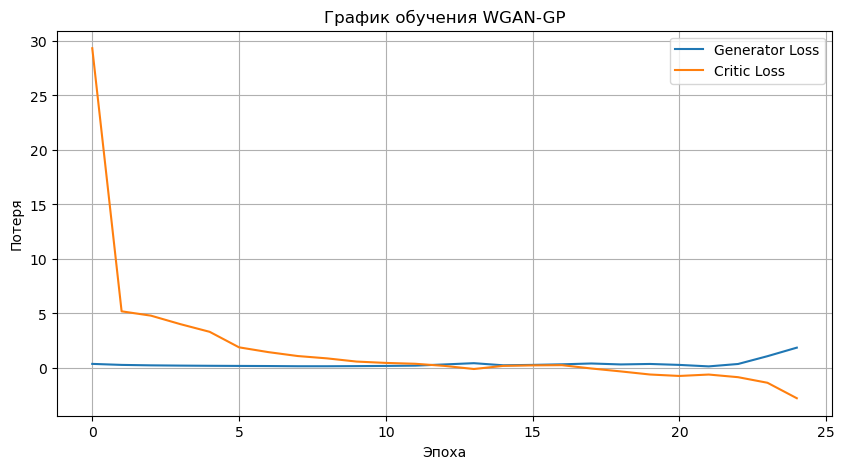

In [58]:
# Визуализация потерь
plt.figure(figsize=(10, 5))
plt.plot(g_losses, label='Generator Loss')
plt.plot(c_losses, label='Critic Loss')
plt.title('График обучения WGAN-GP')
plt.xlabel('Эпоха')
plt.ylabel('Потеря')
plt.legend()
plt.grid(True)
plt.savefig('training_loss.png')
plt.show()

In [59]:
# Визуализация сгенерированных молекул
print("\nВизуализация сгенерированных молекул...")
num_to_visualize = 8
valid_mols = []

# Преобразование SMILES в RDKit молекулы
for sm in valid_smiles[:num_to_visualize]:
    mol = Chem.MolFromSmiles(sm)
    if mol is not None:
        valid_mols.append(mol)

# Визуализация
if valid_mols:
    img = Draw.MolsToGridImage(valid_mols, molsPerRow=4, subImgSize=(200, 200),
                              legends=[f"SMILES {i+1}" for i in range(len(valid_mols))])
    display(img)
else:
    print("Нет валидных молекул для визуализации")


Визуализация сгенерированных молекул...
Нет валидных молекул для визуализации


Вычисление свойств: 100%|████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 5069.95it/s]
Вычисление свойств: 0it [00:00, ?it/s]


TypeError: 'NoneType' object is not iterable

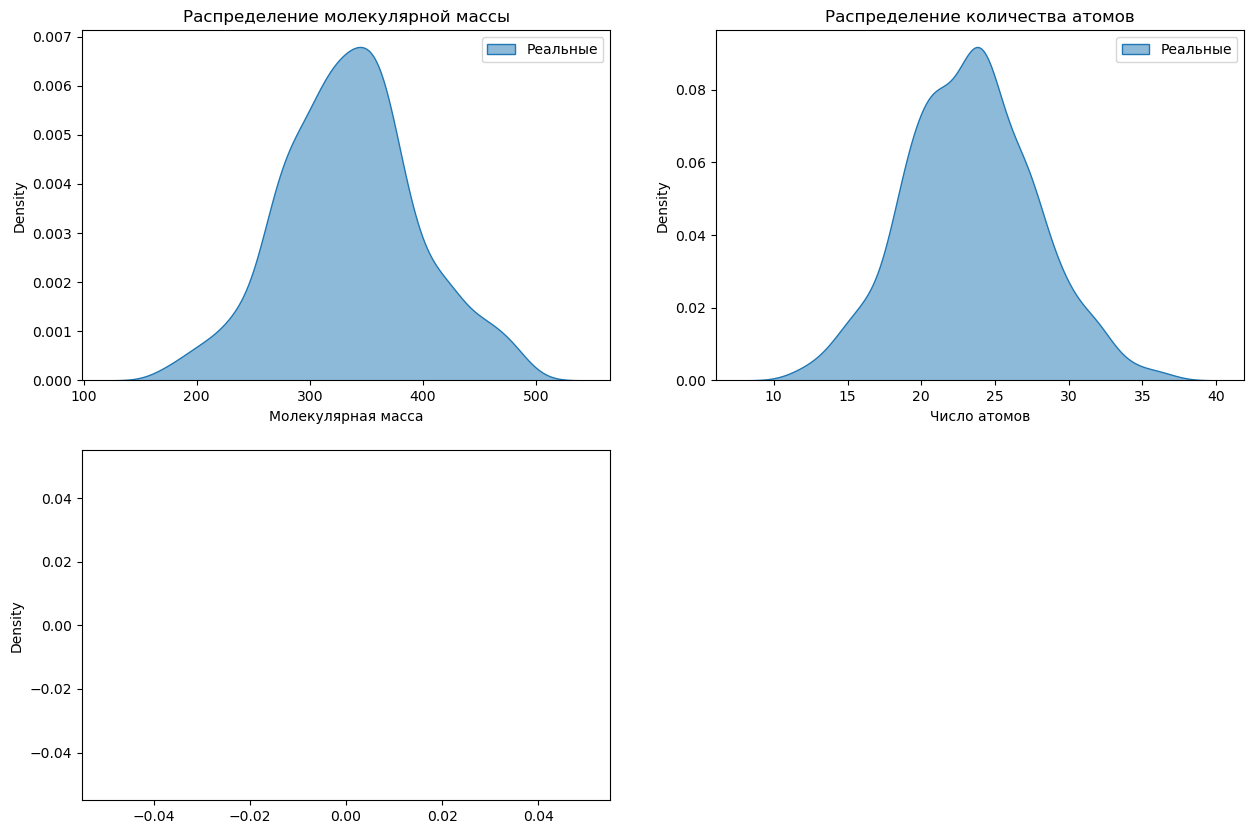

In [60]:
# Сравнение распределений молекулярных свойств
def compute_molecular_properties(smiles_list):
    """Вычисление молекулярных свойств для списка SMILES"""
    properties = {
        'molecular_weight': [],
        'num_atoms': [],
        'num_rings': []
    }

    for sm in tqdm(smiles_list, desc="Вычисление свойств"):
        mol = Chem.MolFromSmiles(sm)
        if mol is not None:
            properties['molecular_weight'].append(Descriptors.MolWt(mol))
            properties['num_atoms'].append(mol.GetNumAtoms())
            properties['num_rings'].append(Chem.GetSSSR(mol))

    return pd.DataFrame(properties)

# Вычисление свойств для реальных и сгенерированных молекул
real_smiles_sample = data['canonical_smiles'].sample(n=1000, random_state=42).tolist()
generated_smiles_sample = valid_smiles[:1000]  # Берем до 1000 валидных

real_props = compute_molecular_properties(real_smiles_sample)
gen_props = compute_molecular_properties(generated_smiles_sample)

# Визуализация распределений
plt.figure(figsize=(15, 10))

# Молекулярная масса
plt.subplot(2, 2, 1)
sns.kdeplot(real_props['molecular_weight'], label='Реальные', fill=True, alpha=0.5)
sns.kdeplot(gen_props['molecular_weight'], label='Сгенерированные', fill=True, alpha=0.5)
plt.title('Распределение молекулярной массы')
plt.xlabel('Молекулярная масса')
plt.legend()

# Количество атомов
plt.subplot(2, 2, 2)
sns.kdeplot(real_props['num_atoms'], label='Реальные', fill=True, alpha=0.5)
sns.kdeplot(gen_props['num_atoms'], label='Сгенерированные', fill=True, alpha=0.5)
plt.title('Распределение количества атомов')
plt.xlabel('Число атомов')
plt.legend()

# Количество колец
plt.subplot(2, 2, 3)
sns.kdeplot(real_props['num_rings'], label='Реальные', fill=True, alpha=0.5)
sns.kdeplot(gen_props['num_rings'], label='Сгенерированные', fill=True, alpha=0.5)
plt.title('Распределение количества колец')
plt.xlabel('Число колец')
plt.legend()

plt.tight_layout()
plt.savefig('property_distributions.png')
plt.show()